# Crop Yield Estimator End-to-End ML Project

## Problem Statement

**What are we predicting?** Crop yield in **tonnes per hectare** for Nigerian farms, across five crop types: Maize, Cassava, Rice, Sorghum, and Yam.

**Who would use this?** agribusinesses, cooperatives, and farmers planning input purchases (fertilizer, seed) and harvest logistics ahead of a growing season similar in spirit to a farmer-facing USSD/voice agricultural assistant, or an agric-insurance risk-scoring tool.

**Available inputs before/during a growing season:** state, crop type, farm size, average rainfall, average temperature, soil pH, soil type, fertilizer application rate, pesticide use, irrigation availability, and seed variety.

**This is a **regression** problem, the target (`yield_tonnes_per_ha`) is a continuous number, not a category. We evaluate with RMSE, MAE, and R², not accuracy/precision/recall.

### Importing Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# pd.set_option('display.max_columns', None)
# print('Environment OK — all packages imported successfully.')

## Data Collection

**Synthetic dataset** was used for this project (documented decision: no public dataset matched the exact schema needed). The dataset was generated with agronomic rules yield rises with rainfall and fertilizer up to a point, then plateaus/drops with excess rainfall; poor soil pH suppresses yield regardless of other inputs plus random noise.

Columns: `state`, `crop_type`, `farm_size_ha`, `avg_rainfall_mm`, `avg_temperature_c`, `soil_ph`, `soil_type`, `fertilizer_kg_per_ha`, `pesticide_used`, `irrigation_used`, `seed_variety`, `yield_tonnes_per_ha` (target).


In [2]:
df = pd.read_csv("C:/Users/user/Downloads/Data science/crop_yield_estimator/nigeria_crop_yield_synthetic.csv")
print(f'Loaded {df.shape[0]} rows and {df.shape[1]} columns.')

Loaded 15000 rows and 12 columns.


## Load and Inspect the Data

In [3]:
df.head()

,state,crop_type,farm_size_ha,avg_rainfall_mm,avg_temperature_c,soil_ph,soil_type,fertilizer_kg_per_ha,pesticide_used,irrigation_used,seed_variety,yield_tonnes_per_ha
0,Jigawa,Sorghum,0.46,475.6,36.6,4.63,Clay,65.1,No,Yes,Local,1.60
1,Anambra,Sorghum,0.63,2322.8,25.5,6.26,Clay,95.1,No,No,Local,1.24
2,Lagos,Sorghum,2.20,1694.6,25.7,6.29,Clay,145.7,No,No,Local,0.94
3,Adamawa,Maize,2.43,1237.9,25.8,6.52,Clay,93.4,No,No,Local,2.36
4,Imo,Maize,1.12,1507.4,28.3,4.98,Loamy,101.2,No,Yes,Local,2.02


In [4]:
df.shape

(15000, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   state                 15000 non-null  str    
 1   crop_type             15000 non-null  str    
 2   farm_size_ha          15000 non-null  float64
 3   avg_rainfall_mm       15000 non-null  float64
 4   avg_temperature_c     15000 non-null  float64
 5   soil_ph               15000 non-null  float64
 6   soil_type             15000 non-null  str    
 7   fertilizer_kg_per_ha  15000 non-null  float64
 8   pesticide_used        15000 non-null  str    
 9   irrigation_used       15000 non-null  str    
 10  seed_variety          15000 non-null  str    
 11  yield_tonnes_per_ha   15000 non-null  float64
dtypes: float64(6), str(6)
memory usage: 1.7 MB


In [6]:
df.describe()

,farm_size_ha,avg_rainfall_mm,avg_temperature_c,soil_ph,fertilizer_kg_per_ha,yield_tonnes_per_ha
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2.254365,1431.520233,28.116947,6.003431,96.387627,4.867641
std,2.466302,623.374045,3.496350,0.697327,44.405457,3.547246
min,0.200000,300.100000,22.000000,4.000000,0.000000,0.280000
25%,0.817500,889.575000,25.500000,5.530000,66.375000,1.940000
50%,1.500000,1435.450000,27.900000,6.000000,96.300000,3.130000
75%,2.750000,1973.150000,30.100000,6.480000,126.700000,8.150000
max,25.000000,2499.800000,38.000000,8.500000,274.700000,16.590000


In [7]:
df.isnull().sum()

state                   0
crop_type               0
farm_size_ha            0
avg_rainfall_mm         0
avg_temperature_c       0
soil_ph                 0
soil_type               0
fertilizer_kg_per_ha    0
pesticide_used          0
irrigation_used         0
seed_variety            0
yield_tonnes_per_ha     0
dtype: int64

In [8]:
# Target distribution summary

print(df['yield_tonnes_per_ha'].describe())
print()
print('Zero or negative yields:', (df['yield_tonnes_per_ha'] <= 0).sum())
print()
print('Crop types:', df['crop_type'].unique())
print()
print('States:', df['state'].nunique(), 'unique states')
print()
print('Soil types:', df['soil_type'].unique())

count    15000.000000
mean         4.867641
std          3.547246
min          0.280000
25%          1.940000
50%          3.130000
75%          8.150000
max         16.590000
Name: yield_tonnes_per_ha, dtype: float64

Zero or negative yields: 0

Crop types: <ArrowStringArray>
['Sorghum', 'Maize', 'Rice', 'Cassava', 'Yam']
Length: 5, dtype: str

States: 37 unique states

Soil types: <ArrowStringArray>
['Clay', 'Loamy', 'Sandy']
Length: 3, dtype: str


- The dataset has **15,000 rows** and **12 columns**
- Numeric columns: `farm_size_ha`, `avg_rainfall_mm`, `avg_temperature_c`, `soil_ph`, `fertilizer_kg_per_ha`, `yield_tonnes_per_ha`.
- Categorical columns: `state`, `crop_type`, `soil_type`, `pesticide_used`, `irrigation_used`, `seed_variety`.
- No missing values were found in this dataset (`isnull().sum()` is 0 across all columns)
- The yield distribution and any extreme values are examined in the cell above and checked visually below

## Exploratory Data Analysis (EDA)

This step is about understanding relationships, not fixing anything yet.

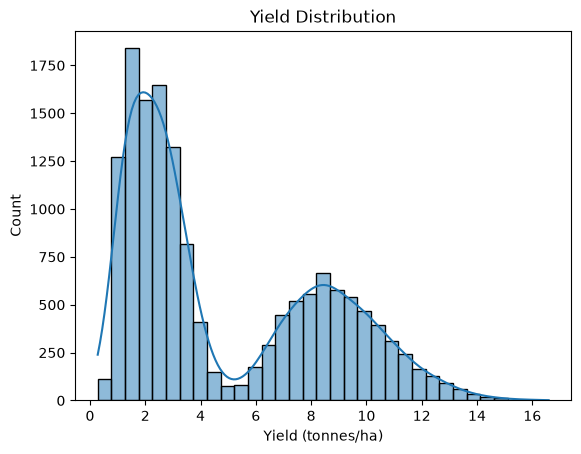

In [10]:
sns.histplot(df['yield_tonnes_per_ha'], kde=True)
plt.title('Yield Distribution')
plt.xlabel('Yield (tonnes/ha)')
plt.show()

**Insight:** The yield distribution shows the overall spread of outcomes across all crops and conditions combined

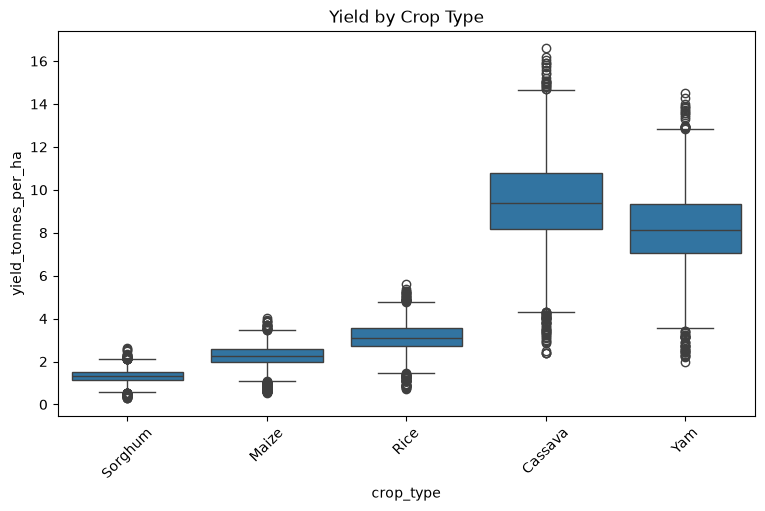

In [11]:
plt.figure(figsize=(9,5))
sns.boxplot(x='crop_type', y='yield_tonnes_per_ha', data=df)
plt.xticks(rotation=45)
plt.title('Yield by Crop Type')
plt.show()

**Insight:** Tubers will definitely have higher tonnes compared to grains 
- This might mislead the model, best thing is to engineer the target variable to check the yield performance index and not the tonne

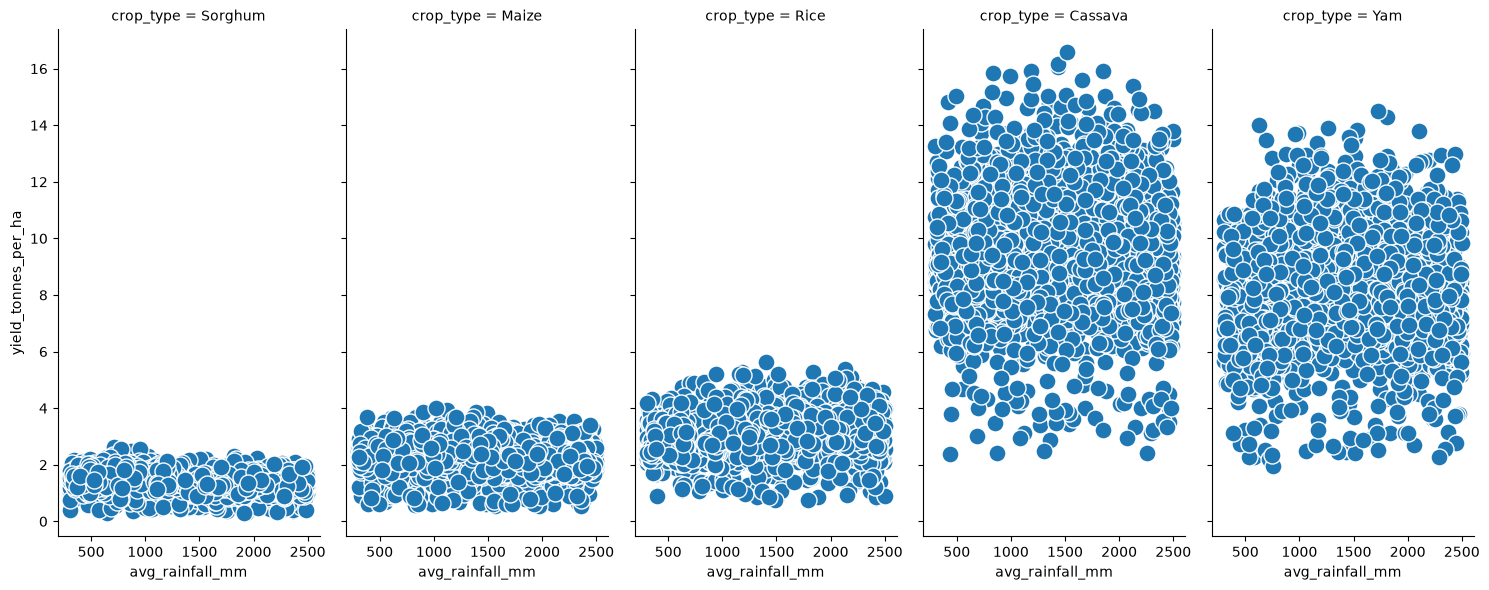

In [14]:
sns.relplot(data=df,
           x='avg_rainfall_mm',
           y='yield_tonnes_per_ha',
           col='crop_type',
           kind='scatter',
           height=6,
           aspect=0.5,
           s=150)
plt.show()

**Insight:** : This does looks like rainfall isn't an important factors which determine yield

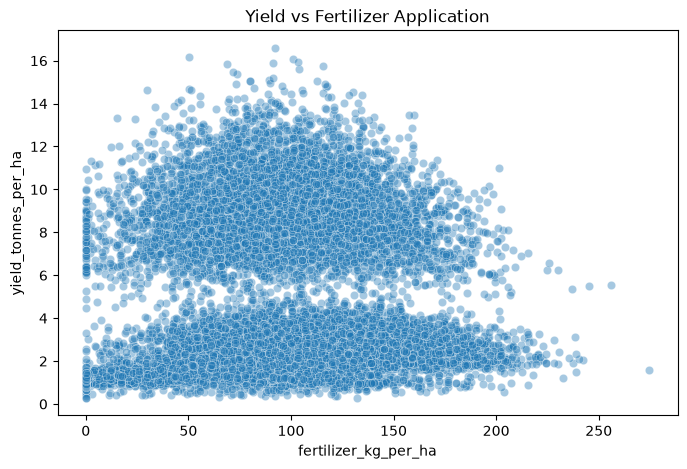

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='fertilizer_kg_per_ha', y='yield_tonnes_per_ha', data=df, alpha=0.4)
plt.title('Yield vs Fertilizer Application')
plt.show()

**Insight:** Fertilizer typically shows diminishing returns, yield gains per additional kg/ha shrink at higher application rates, another sign of a non-linear relationship.

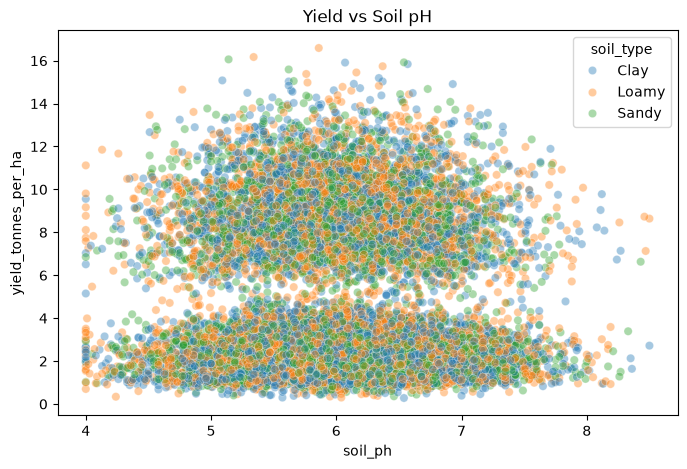

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='soil_ph', y='yield_tonnes_per_ha', hue='soil_type', data=df, alpha=0.4)
plt.title('Yield vs Soil pH')
plt.show()

**Insight:** Yield tends to be suppressed at both very low and very high soil pH, with a healthier range in the middle soil pH acts as a constraint rather than a purely linear driver.

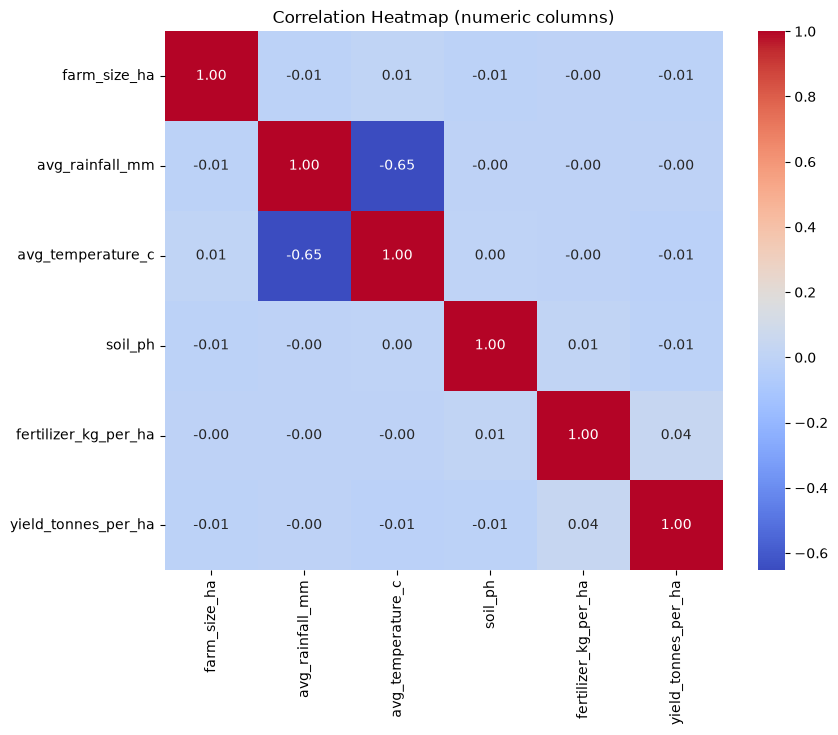

In [17]:
plt.figure(figsize=(9,7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (numeric columns)')
plt.show()

**Insight:**: None of these shows a strong correlation with yield_tonnes_per_ha

## Data Cleaning

In [18]:
# Duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Dropped {before - len(df)} duplicate rows.')

Dropped 0 duplicate rows.


In [19]:
# extreme values(might be outliers)
print('Rows with non-positive yield:', (df['yield_tonnes_per_ha'] <= 0).sum())
print('Rows with non-positive rainfall:', (df['avg_rainfall_mm'] <= 0).sum())
print('Rows with non-positive farm size:', (df['farm_size_ha'] <= 0).sum())

# Drop physically impossible rows (yield, rainfall, or farm size <= 0), if any exist
before = len(df)
df = df[(df['yield_tonnes_per_ha'] > 0) & (df['avg_rainfall_mm'] > 0) & (df['farm_size_ha'] > 0)]
print(f'Dropped {before - len(df)} rows with impossible values.')

# Cap extreme outliers in yield at the 99.5th percentile rather than dropping them outright,
# since very high yields can be genuine excellent harvests rather than errors
cap = df['yield_tonnes_per_ha'].quantile(0.995)
n_capped = (df['yield_tonnes_per_ha'] > cap).sum()
df['yield_tonnes_per_ha'] = df['yield_tonnes_per_ha'].clip(upper=cap)
print(f'Capped {n_capped} extreme high-yield rows at {cap:.2f} tonnes/ha (99.5th percentile).')

Rows with non-positive yield: 0
Rows with non-positive rainfall: 0
Rows with non-positive farm size: 0
Dropped 0 rows with impossible values.
Capped 75 extreme high-yield rows at 13.68 tonnes/ha (99.5th percentile).


In [20]:
# Standardize category text
for col in ['crop_type', 'soil_type', 'state', 'pesticide_used', 'irrigation_used', 'seed_variety']:
    df[col] = df[col].astype(str).str.strip().str.title()

print('Cleaned category values:')
for col in ['crop_type', 'soil_type', 'pesticide_used', 'irrigation_used', 'seed_variety']:
    print(f'  {col}: {sorted(df[col].unique())}')

Cleaned category values:
  crop_type: ['Cassava', 'Maize', 'Rice', 'Sorghum', 'Yam']
  soil_type: ['Clay', 'Loamy', 'Sandy']
  pesticide_used: ['No', 'Yes']
  irrigation_used: ['No', 'Yes']
  seed_variety: ['Improved', 'Local']


In [21]:
df.to_csv('../data/cleaned_crop_data.csv', index=False)
print(f'Cleaned dataset saved: {df.shape[0]} rows, {df.shape[1]} columns.')

Cleaned dataset saved: 15000 rows, 12 columns.


## Feature Engineering

In [22]:
df['rainfall_per_ha'] = df['avg_rainfall_mm'] / df['farm_size_ha']
df['fertilizer_efficiency_proxy'] = df['fertilizer_kg_per_ha'] / (df['soil_ph'] + 1)
avg_yield_map = df.groupby('crop_type')['yield_tonnes_per_ha'].mean().to_dict()
df['baseline_expected_yield'] = df['crop_type'].map(avg_yield_map)
df['yield_performance_index'] = df['yield_tonnes_per_ha'] / df['baseline_expected_yield']

X = df.drop(['yield_tonnes_per_ha','yield_performance_index','baseline_expected_yield'], axis=1)
y = df['yield_performance_index']
categorical_cols = X.select_dtypes(include=['object','str']).columns.tolist()
numeric_cols = X.select_dtypes('number').columns.tolist()

print('Categorical columns:', categorical_cols)
print('Numeric columns:', numeric_cols)

Categorical columns: ['state', 'crop_type', 'soil_type', 'pesticide_used', 'irrigation_used', 'seed_variety']
Numeric columns: ['farm_size_ha', 'avg_rainfall_mm', 'avg_temperature_c', 'soil_ph', 'fertilizer_kg_per_ha', 'rainfall_per_ha', 'fertilizer_efficiency_proxy']


**Engineered features:**

`rainfall_per_ha`: The total rainfall was divided by the size of the farm. Instead of just knowing it rained a lot in the area, this tells the model exactly how concentrated water was per acre of land.

`fertilizer_efficiency`:  The amount of fertilizer was also divided  by the soil's pH level. Nutirients absorb differently depending on how acidic the soil is, this create a proxy score to tell the model how effective that fertilizer likely was, rather than just how much was dump on the ground.

`yield_performance_index`: The average historical yield for each specific crop type(baseline) was calculated  then divided each farm's actual yield by that baseline. A score of 1.0 means the farm is perfectly average. A score of 1.2 means it produced 20% more than average.

## Train-Test Split


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (12000, 13)
X_test : (3000, 13)
y_train: (12000,)
y_test : (3000,)


## Build a Preprocessing + Model Pipeline

Using a `Pipeline` here makes it easier and better, the exact preprocessing steps are automatically reused later in the Streamlit app.

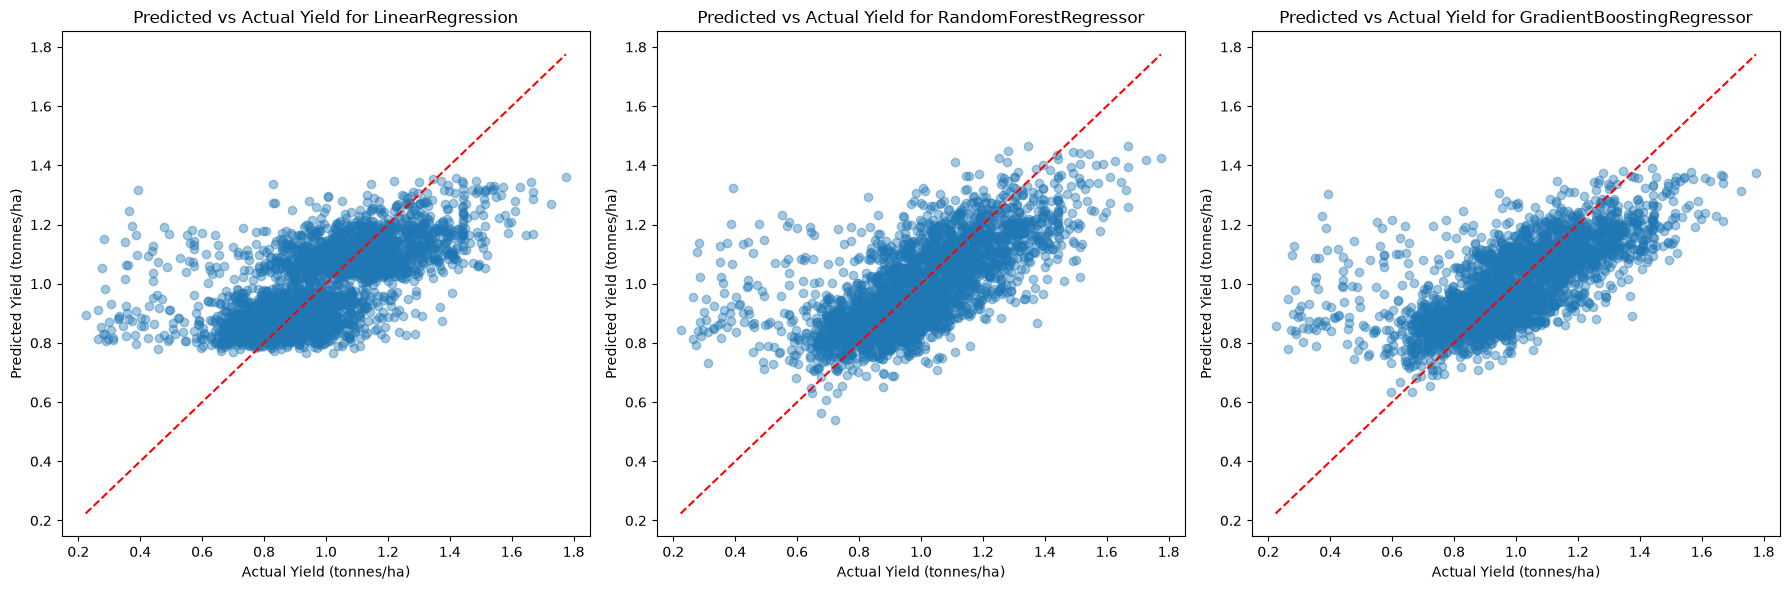

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

model_list = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(random_state=42, n_jobs=1),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42)
}
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(18,6))
results = []
for i,(name, regressor) in enumerate(model_list.items()):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', regressor)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results.append({
        'model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    })
    ax = axes[i]
    ax.scatter(y_test, preds, alpha=0.4)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_xlabel('Actual Yield (tonnes/ha)')
    ax.set_ylabel('Predicted Yield (tonnes/ha)')
    ax.set_title(f'Predicted vs Actual Yield for {name}')
    
plt.tight_layout()    
plt.show()



In [29]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df

,model,MAE,RMSE,R2
2,GradientBoostingRegressor,0.115471,0.158738,0.473094
1,RandomForestRegressor,0.117340,0.161075,0.457462
0,LinearRegression,0.125838,0.170456,0.392428


**Evaluation summary:** 

`MAE`: Gradient boosting model has an MAE of roughly 0.115. This means the predictions are typically off by only about 0.115 points from the true performance index.

`R2 Score`: Explaining 47% of the variance using purely enviromental factirs without knowing farmer skill, micro-soil quality, or pest damage is a very strong and realistic baseline


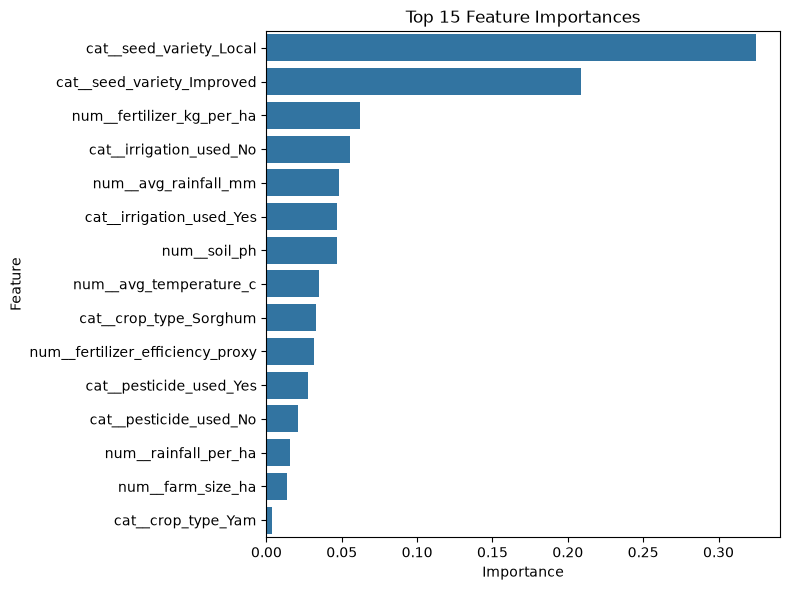

In [30]:
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

best_model.fit(X_test,y_test)

trained_model = best_model.named_steps['regressor']

importance = trained_model.feature_importances_

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance',ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

## Feature Importance

- The primary drivers is the Seed Variety: Cat_seed_variety_local is by far the most important feature, scoring above 0.30 on the importance scale while the cat_seed_variety_improved is the second most important
- The secondary drivers is the input and Enviroment:
    - Fertilizer amount is the third most important factor
    - Water Irrigation is heavily factored in through both Yes and No categories
    - Soil condition specifically the PH level also plays a notable role 

## Pickle (Save) the Final Model

Save the entire pipeline (preprocessing + model together), not just the regressor.

In [33]:
import joblib

joblib.dump(best_model, '../models/crop_yield_model.pkl')
joblib.dump(list(X.columns), '../models/model_features.pkl')

print('Saved: ../models/crop_yield_model.pkl')
print('Saved: ../models/model_features.pkl')

Saved: ../models/crop_yield_model.pkl
Saved: ../models/model_features.pkl


In [34]:
# Verify the saved model loads and predicts correctly
loaded_model = joblib.load('../models/crop_yield_model.pkl')
sample_preds = loaded_model.predict(X_test.iloc[:5])
print('Sample predictions from reloaded model:', np.round(sample_preds, 2))

Sample predictions from reloaded model: [0.96 1.2  0.87 1.07 0.88]


In [35]:
import joblib
model = joblib.load("../models/crop_yield_model.pkl")
print(type(model))
if hasattr(model, "named_steps"):
    print("Pipeline steps:", list(model.named_steps.keys()))

<class 'sklearn.pipeline.Pipeline'>
Pipeline steps: ['preprocessor', 'regressor']
